In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, make_scorer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import os
import json
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
import xgboost as xgb # xgb.__version__ '2.1.3'
from catboost import CatBoostRegressor
import optuna
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [2]:
data=pd.read_excel("../Data/MTR/processed_mtr_data.xlsx",engine="openpyxl")
original_data=data.copy()
data=data.drop(columns='COST_INDEX')

In [3]:
data.rename(columns={
    '按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2': 'median_monthly_income_by_gender_excluding_unpaid_family_workers',
    '按房屋類型劃分的有人居住的屋宇單位數目.3': 'occupied_housing_units_by_type',
    '按房屋類型劃分的家庭住戶數目.3': 'households_by_housing_type',
    '家庭住戶每月按揭供款及借貸還款與收入比率中位數': 'median_mortgage_repayment_to_income_ratio',
    '按上課地點劃分的於香港院校就讀全日制課程的人口.2': 'full_time_students_by_institution_location',
    '按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2': 'households_by_number_of_rooms',
    '家庭住戶平均人數': 'average_household_size',
    '按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2': 'households_with_mortgage_by_repayment_amount',
    '按房屋類型劃分的人口.3': 'population_by_housing_type',
    '按行業(9)劃分的工作人口.3': 'working_population_by_industry_9_categories',
    '按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目': 'households_by_monthly_rent',
    '按行業(9)劃分的工作人口.5': 'working_population_by_industry_5_categories',
    '按工作地點劃分的工作人口.2': 'working_population_by_work_location',
    '按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4': 'working_population_by_monthly_income_excluding_unpaid_family_workers',
    '按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4': 'working_population_by_monthly_income_excluding_foreign_domestic_workers',
    '按住戶人數劃分的家庭住戶數目': 'households_by_size',
    '按住戶結構劃分的家庭住戶數目.6': 'households_by_structure',
    'Price':'PRICE'
}, inplace=True)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 30 columns):
 #   Column                                                                   Non-Null Count  Dtype  
---  ------                                                                   --------------  -----  
 0   PRICE                                                                    514 non-null    float64
 1   DISTANCE                                                                 514 non-null    float64
 2   median_monthly_income_by_gender_excluding_unpaid_family_workers          514 non-null    int64  
 3   occupied_housing_units_by_type                                           514 non-null    int64  
 4   households_by_housing_type                                               514 non-null    int64  
 5   median_mortgage_repayment_to_income_ratio                                514 non-null    float64
 6   full_time_students_by_institution_location                               5

In [5]:
TARGET='PRICE'

In [6]:
def clean_non_ascii(text):
    if isinstance(text, str):
        return ''.join([char if ord(char) < 128 else '' for char in text])
    return text

data = data.map(clean_non_ascii)

In [7]:
train, test = train_test_split(data, test_size=0.3, random_state=42)

In [8]:
X = train.drop([TARGET], axis=1)
y = train[TARGET]
X_test = test.drop([TARGET], axis=1)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)

In [9]:
import lightgbm as lgb
import time
n_fold = 10

import matplotlib.pyplot as plt
folds = KFold(n_splits=n_fold, shuffle=True, random_state=42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import shap

def train_model(X, X_test, y, params=None, folds=folds, model_type='lgb', plot_feature_importance=False, model=None, importance_threshold=0):

    oof = np.zeros(X.shape[0])
    prediction = np.zeros(X_test.shape[0])
    scores = []
    feature_importance = pd.DataFrame()
    # 初始化SHAP值存储
    all_shap_values = []
    all_X_valid = []
    # Step 1: Train and record feature importances
    for fold_n, (train_index, valid_index) in enumerate(folds.split(X)):
        print('Fold', fold_n, 'started at', time.ctime())
        if model_type == 'sklearn':
            X_train, X_valid = X[train_index], X[valid_index]
        else:
            X_train, X_valid = X.values[train_index], X.values[valid_index]
        # y_train, y_valid = y[train_index], y[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index] 

        if model_type == 'lgb':
            model = lgb.LGBMRegressor(**params, n_estimators=20000, nthread=4, n_jobs=-1)
            model.fit(X_train, y_train, 
                      eval_set=[(X_train, y_train), (X_valid, y_valid)], eval_metric='rmse')
            
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test, num_iteration=model.best_iteration_)
            # 计算当前折的SHAP值
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_valid)
            
            # 保存SHAP值和验证集数据
            all_shap_values.append(shap_values)
            all_X_valid.append(X_valid)          
        
        elif model_type == 'xgb':
            train_data = xgb.DMatrix(data=X_train, label=y_train)
            valid_data = xgb.DMatrix(data=X_valid, label=y_valid)

            watchlist = [(train_data, 'train'), (valid_data, 'valid_data')]
            model = xgb.train(dtrain=train_data, num_boost_round=20000, evals=watchlist, early_stopping_rounds=200, verbose_eval=500, params=params)
            y_pred_valid = model.predict(xgb.DMatrix(X_valid), iteration_range=(0, model.best_iteration + 1))
            y_pred = model.predict(xgb.DMatrix(X_test.values),  iteration_range=(0, model.best_iteration + 1))
        
        elif model_type == 'sklearn':
            model = model
            model.fit(X_train, y_train)
            y_pred_valid = model.predict(X_valid).reshape(-1,)
            score = mean_squared_error(y_valid, y_pred_valid)
            
            y_pred = model.predict(X_test)
        
        elif model_type == 'cat':
            model = CatBoostRegressor(iterations=20000,  eval_metric='RMSE', **params)
            model.fit(X_train, y_train, eval_set=(X_valid, y_valid), cat_features=[], use_best_model=True, verbose=False)

            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)

        elif model_type == 'randomforest':
            model = RandomForestRegressor(**params, n_jobs=-1, random_state=42)
            model.fit(X_train, y_train)
            y_pred_valid = model.predict(X_valid)
            y_pred = model.predict(X_test)

        oof[valid_index] = y_pred_valid.reshape(-1,)
        mse = mean_squared_error(y_valid, y_pred_valid) ** 0.5
        print("mse----------->", mse)
        scores.append(mse)
        
        prediction += y_pred

        if model_type == 'lgb':
            # Calculate feature importance for each fold
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = X.columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)
        elif model_type =='randomforest':
            # Calculate feature importance for each fold
            fold_importance = pd.DataFrame()
            fold_importance["feature"] = X.columns
            fold_importance["importance"] = model.feature_importances_
            fold_importance["fold"] = fold_n + 1
            feature_importance = pd.concat([feature_importance, fold_importance], axis=0)

    prediction /= folds.n_splits
    
    print('CV mean score: {0:.4f}, std: {1:.4f}.'.format(np.mean(scores), np.std(scores)))

    if model_type == 'lgb':
        feature_importance["importance"] /= folds.n_splits
            # 合并所有折的SHAP值
        combined_shap = np.vstack(all_shap_values)  # 形状: (n_samples_total, n_features)
        combined_X_valid = np.vstack(all_X_valid)   # 形状: (n_samples_total, n_features)
        
        # 绘制SHAP汇总图（所有折的综合结果）
        # 截断过长的字段名（保留前10个字符 + '...'）
        shortened_names = [name[:30] + '...' if len(name) > 10 else name for name in X.columns]
        # shortened_names = [name.replace('_', '_\n') if len(name) > 15 else name for name in X.columns]
        plt.figure(figsize=(10, 20))
        shap.summary_plot(combined_shap, combined_X_valid, feature_names=shortened_names, show=False)
        plt.title(f'SHAP value for {model_type}-MTR', fontsize=14)  # 自定义标题
        # plt.tight_layout()
        plt.show()
        # Optional: Plot feature importance if specified
        if plot_feature_importance:
            cols = feature_importance[["feature", "importance"]].groupby("feature").mean().sort_values(
                by="importance", ascending=False)[:50].index
            best_features = feature_importance.loc[feature_importance.feature.isin(cols)]

            plt.figure(figsize=(16, 12))
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
            plt.title('LGB Features (avg over folds)')
            return oof, prediction, feature_importance
        return oof, prediction, feature_importance            
    elif model_type =='randomforest':
        feature_importance["importance"] /= folds.n_splits
        if plot_feature_importance:
            #plot the frature importance 
            cols = feature_importance.groupby("feature")["importance"].mean().sort_values(ascending=False)[:50].index
            best_features = feature_importance[feature_importance["feature"].isin(cols)]

            # 绘制条形图
            plt.figure(figsize=(16, 12))
            sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
            plt.title('Random Forest Feature Importance (Avg over Folds)')
            plt.tight_layout()
            return oof, prediction, feature_importance
        return oof, prediction, feature_importance

    else:
        return oof, prediction


In [10]:
X_train_np = X_train.values
y_train_np = y_train.values
X_valid_np = X_valid.values
y_valid_np = y_valid.values
X_train_np = np.nan_to_num(X_train_np, nan=0)
X_valid_np = np.nan_to_num(X_valid_np, nan=0)

from xgboost.callback import EarlyStopping
from lightgbm import early_stopping, log_evaluation

def objective(trial, model_type):
    if model_type == 'xgboost':
        param = {
            'objective': 'reg:squarederror',
            'eta': trial.suggest_float('eta', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
            'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'eval_metric':'rmse',
            'early_stopping_rounds':50,
            'n_estimators': 1000
        }
        model = xgb.XGBRegressor(**param, n_jobs=-1, random_state=42)

    elif model_type == 'lightgbm':
        param = {
            'objective': 'regression',
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', -1, 10),
            'num_leaves': trial.suggest_int('num_leaves', 2, 256),
            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 1, 20),
            'n_estimators': 1000,
            'verbosity': -1  # Suppress warnings
        }
        model = lgb.LGBMRegressor(**param, n_jobs=-1, random_state=42)

        callbacks = [early_stopping(stopping_rounds=50, verbose=False)]

    elif model_type == 'catboost':
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 3, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 10.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
            'od_wait': trial.suggest_int('od_wait', 10, 200),
            'iterations': 1000,
            'eval_metric': 'RMSE',  # Specify evaluation metric here
            'random_state': 42,
            'silent': True  # Suppress output
        }
        model = CatBoostRegressor(**param)
    elif model_type == 'randomforest':
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**param)


    else:
        raise ValueError(f"Unknown model type: {model_type}")

    # Train the model
    if model_type == 'lightgbm':
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)],
            eval_metric='rmse',
            callbacks=callbacks
        )
    elif model_type == 'catboost':
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)]
        )
    elif model_type=='randomforest':
        model.fit(
            X_train_np, y_train_np
        )
    else:
        model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_valid_np, y_valid_np)],
            #early_stopping_rounds=50,  
            verbose=False
        )

    # Predict and calculate RMSE
    y_pred = model.predict(X_valid_np)
    rmse = np.sqrt(mean_squared_error(y_valid_np, y_pred))
    return rmse

def optimize_model(model_type, n_trials=10):
    def wrapped_objective(trial):
        return objective(trial, model_type)

    study = optuna.create_study(direction='minimize')
    study.optimize(wrapped_objective, n_trials=n_trials)
    print(f"Best parameters for {model_type}:")
    print(study.best_trial.params)
    print(f"Best RMSE for {model_type}: {study.best_trial.value}")
    return study

In [11]:
lgb_study = optimize_model('lightgbm')

[I 2025-04-29 20:08:19,917] A new study created in memory with name: no-name-91a848fe-253f-4a9b-9fa6-ea18e5513bba
[I 2025-04-29 20:08:20,000] Trial 0 finished with value: 1.9064900925992623 and parameters: {'learning_rate': 0.028796891036141498, 'max_depth': 0, 'num_leaves': 26, 'feature_fraction': 0.9905463507059455, 'bagging_fraction': 0.7579185819921528, 'lambda_l1': 0.00011930162879272914, 'lambda_l2': 8.4854907192297e-06, 'min_child_samples': 2}. Best is trial 0 with value: 1.9064900925992623.
[I 2025-04-29 20:08:20,180] Trial 1 finished with value: 2.25472120861877 and parameters: {'learning_rate': 0.028246046841923673, 'max_depth': -1, 'num_leaves': 80, 'feature_fraction': 0.698806776583027, 'bagging_fraction': 0.9918897428025875, 'lambda_l1': 1.2206054813062107e-05, 'lambda_l2': 2.2526561864490536e-07, 'min_child_samples': 19}. Best is trial 0 with value: 1.9064900925992623.
[I 2025-04-29 20:08:20,294] Trial 2 finished with value: 2.299449388362742 and parameters: {'learning_ra

Best parameters for lightgbm:
{'learning_rate': 0.15371269294987014, 'max_depth': 9, 'num_leaves': 170, 'feature_fraction': 0.9670991590567914, 'bagging_fraction': 0.6714549811648471, 'lambda_l1': 0.13588854108828766, 'lambda_l2': 0.0004957279675729277, 'min_child_samples': 14}
Best RMSE for lightgbm: 1.4521736370770537


In [12]:
oof_lgb, prediction_lgb, _ = train_model(X, X_test, y, params=lgb_study.best_params, model_type='lgb', plot_feature_importance=True)


Fold 0 started at Tue Apr 29 20:08:22 2025
mse-----------> 3.175104259041943
Fold 1 started at Tue Apr 29 20:08:27 2025


KeyboardInterrupt: 

In [ ]:
rf_study = optimize_model('randomforest', n_trials=50)

[I 2025-04-13 13:44:32,878] A new study created in memory with name: no-name-3a8ad54e-5f66-4447-9838-e300ed35b397
[I 2025-04-13 13:44:34,166] Trial 0 finished with value: 0.883767922440091 and parameters: {'n_estimators': 865, 'max_depth': 24, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.883767922440091.
[I 2025-04-13 13:44:34,757] Trial 1 finished with value: 0.8573520224066463 and parameters: {'n_estimators': 375, 'max_depth': 13, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8573520224066463.
[I 2025-04-13 13:44:34,930] Trial 2 finished with value: 0.876823402275006 and parameters: {'n_estimators': 104, 'max_depth': 13, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 1 with value: 0.8573520224066463.
[I 2025-04-13 13:44:35,275] Trial 3 finished with value: 0.8876801596651739 and parameters: {'n_estimators': 196, 'max_depth': 21, 'mi

Best parameters for randomforest:
{'n_estimators': 131, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2'}
Best RMSE for randomforest: 0.794255032365291


In [ ]:
rf_study.best_params

{'n_estimators': 131,
 'max_depth': 23,
 'min_samples_split': 9,
 'min_samples_leaf': 3,
 'max_features': 'log2'}

Fold 0 started at Sun Apr 13 19:27:26 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 4.586650493174376
Fold 1 started at Sun Apr 13 19:27:26 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 0.38489453290076486
Fold 2 started at Sun Apr 13 19:27:26 2025


...

mse-----------> 0.6735437564077981
Fold 8 started at Sun Apr 13 19:27:28 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 1.8529339289458624
Fold 9 started at Sun Apr 13 19:27:28 2025


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


mse-----------> 0.6952367592165372
CV mean score: 1.4781, std: 1.2777.


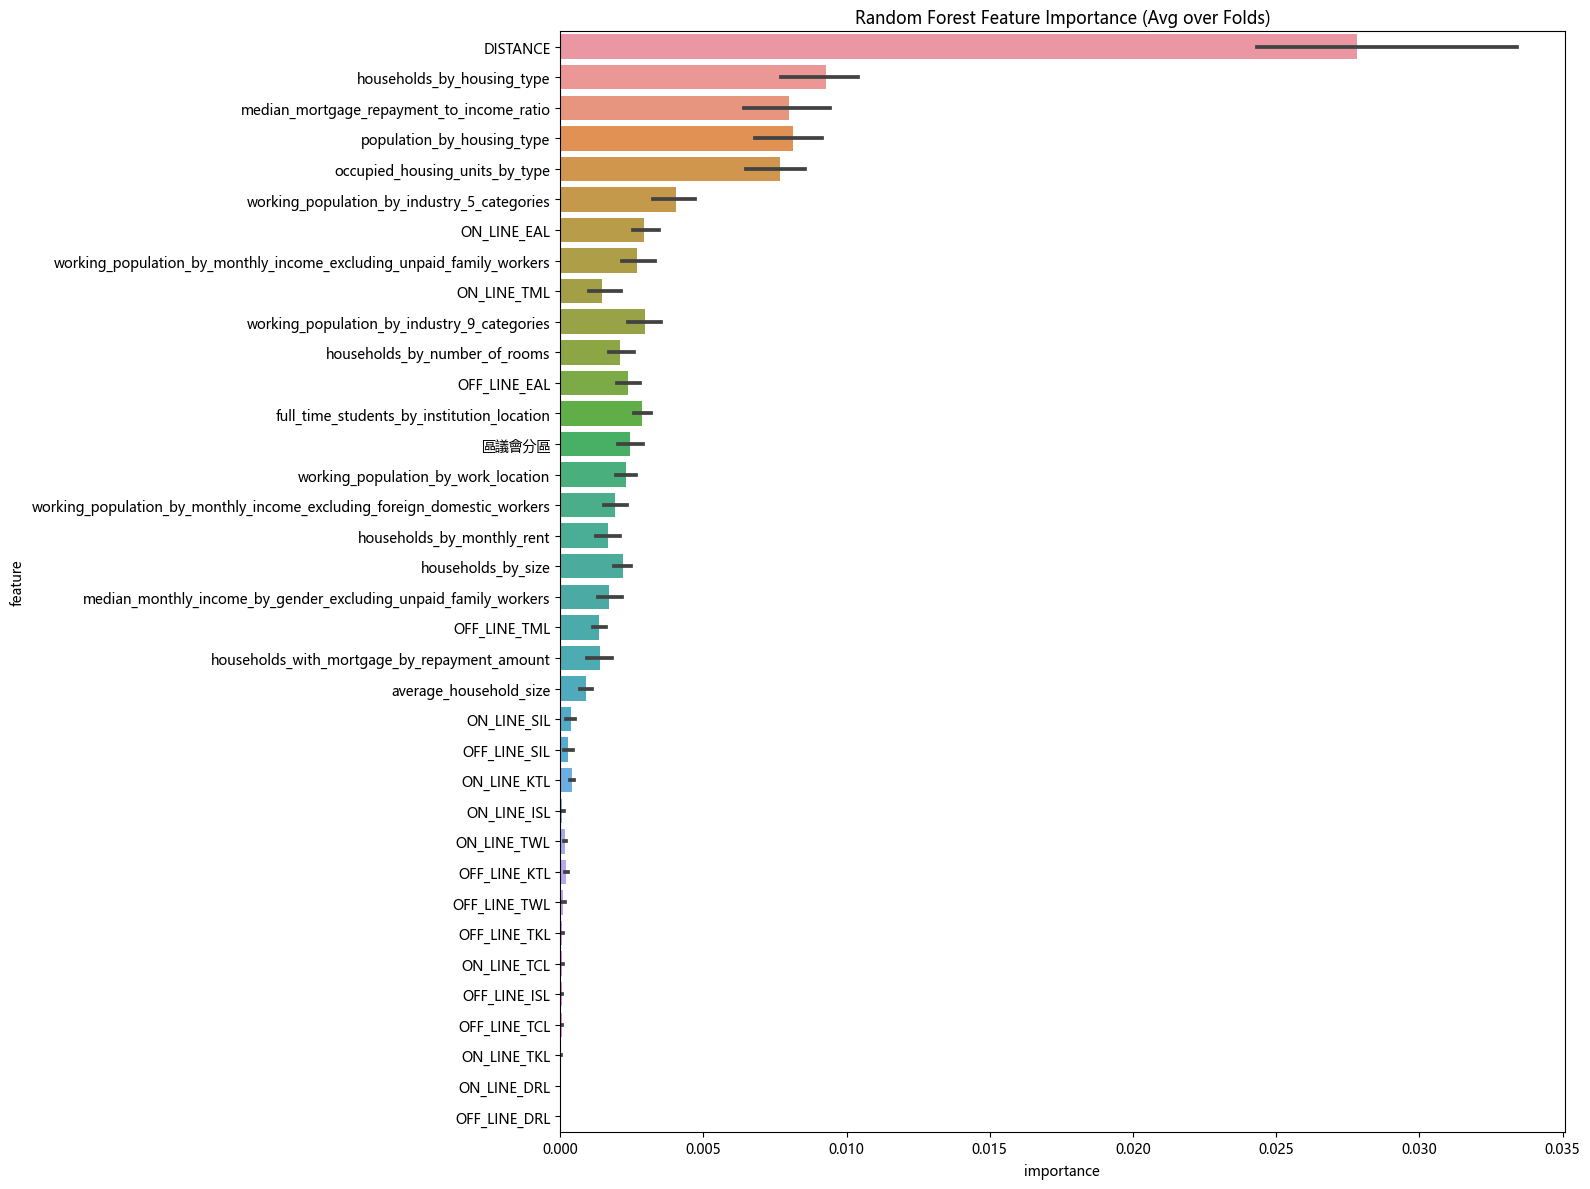

In [ ]:
oof_rf, prediction_rf,feature_importance= train_model(X, X_test, y, params=rf_study.best_params, model_type='randomforest', plot_feature_importance=True)


In [ ]:
catboost_study = optimize_model('catboost')

[I 2025-04-13 13:45:04,318] A new study created in memory with name: no-name-40ecce81-de41-4d52-853f-71476004f2e3
[I 2025-04-13 13:45:04,709] Trial 0 finished with value: 1.106007821565291 and parameters: {'learning_rate': 0.016892184122313355, 'depth': 3, 'l2_leaf_reg': 1.0394677631924503, 'bagging_temperature': 9.679326453490171, 'colsample_bylevel': 0.7106490306234957, 'od_wait': 187}. Best is trial 0 with value: 1.106007821565291.
[I 2025-04-13 13:45:04,824] Trial 1 finished with value: 0.9763510594838912 and parameters: {'learning_rate': 0.15251778450162906, 'depth': 3, 'l2_leaf_reg': 0.00025334602212403556, 'bagging_temperature': 3.0142027801531777, 'colsample_bylevel': 0.8958559047640486, 'od_wait': 59}. Best is trial 1 with value: 0.9763510594838912.
[I 2025-04-13 13:45:09,835] Trial 2 finished with value: 0.6442988699773288 and parameters: {'learning_rate': 0.013147995363492761, 'depth': 10, 'l2_leaf_reg': 0.005556360783960924, 'bagging_temperature': 6.550678092833611, 'colsam

Best parameters for catboost:
{'learning_rate': 0.013147995363492761, 'depth': 10, 'l2_leaf_reg': 0.005556360783960924, 'bagging_temperature': 6.550678092833611, 'colsample_bylevel': 0.6480459162125815, 'od_wait': 91}
Best RMSE for catboost: 0.6442988699773288


In [ ]:
catboost_study.best_params

{'learning_rate': 0.013147995363492761,
 'depth': 10,
 'l2_leaf_reg': 0.005556360783960924,
 'bagging_temperature': 6.550678092833611,
 'colsample_bylevel': 0.6480459162125815,
 'od_wait': 91}

In [ ]:

oof_cat, prediction_cat = train_model(X, X_test, y, params=catboost_study.best_params, model_type='cat')


Fold 0 started at Sun Apr 13 13:45:21 2025
mse-----------> 2.175047433143287
Fold 1 started at Sun Apr 13 13:45:26 2025
mse-----------> 0.21843905833201457
Fold 2 started at Sun Apr 13 13:45:48 2025
mse-----------> 0.34710266766427456
Fold 3 started at Sun Apr 13 13:45:54 2025
mse-----------> 0.39934224216390685
Fold 4 started at Sun Apr 13 13:46:19 2025
mse-----------> 0.49792598065394866
Fold 5 started at Sun Apr 13 13:46:22 2025
mse-----------> 0.4565132372664075
Fold 6 started at Sun Apr 13 13:46:25 2025
mse-----------> 0.6885485163904067
Fold 7 started at Sun Apr 13 13:46:28 2025
mse-----------> 0.46362625073697683
Fold 8 started at Sun Apr 13 13:48:23 2025
mse-----------> 0.3914639032333658
Fold 9 started at Sun Apr 13 13:48:31 2025
mse-----------> 0.5614057640476646
CV mean score: 0.6199, std: 0.5319.


In [ ]:
train_stack = np.vstack([oof_lgb, oof_cat,oof_rf]).transpose()
train_stack = pd.DataFrame(train_stack, columns=['lgb', 'cat','rf'])
test_stack = np.vstack([prediction_lgb, prediction_cat,prediction_rf]).transpose()
test_stack = pd.DataFrame(test_stack, columns=['lgb', 'cat','rf'])
model = linear_model.RidgeCV(alphas=(0.01, 0.1, 1.0, 10.0, 100.0), scoring='neg_mean_squared_error', cv=folds)
oof_rcv_stack, prediction_rcv_stack = train_model(train_stack.values, test_stack.values, y, params=None, model_type='sklearn', model=model)

Fold 0 started at Sun Apr 13 13:48:37 2025
mse-----------> 2.208369866216765
Fold 1 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.26168394042399556
Fold 2 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.3639909295863605
Fold 3 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.5497693203751084
Fold 4 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.6469888822731547
Fold 5 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.5540535242931767
Fold 6 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.7381423984075559
Fold 7 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.5247855762555168
Fold 8 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.7584894286499594
Fold 9 started at Sun Apr 13 13:48:38 2025
mse-----------> 0.5975916466247173
CV mean score: 0.7204, std: 0.5166.


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lgb_rmse = np.sqrt(mean_squared_error(test[TARGET], prediction_lgb))
rf_rmse=np.sqrt(mean_squared_error(test[TARGET], prediction_rf))
cat_rmse=np.sqrt(mean_squared_error(test[TARGET], prediction_cat))
rcv_stack_rmse=np.sqrt(mean_squared_error(test[TARGET], prediction_rcv_stack))
lgb_r2=r2_score(test[TARGET], prediction_lgb)
rf_r2=r2_score(test[TARGET], prediction_rf)
cat_r2=r2_score(test[TARGET], prediction_cat)
rcv_stack_r2=r2_score(test[TARGET], prediction_rcv_stack)
print(prediction_lgb)


print("LGB_RMSE:", lgb_rmse)
print("RF_RMSE:", rf_rmse)
print("CAT_RMSE:", cat_rmse)
print("RCV_STACK_RMSE:", rcv_stack_rmse)
print('LGB_R2: ', lgb_r2)
print('RF_R2: ', rf_r2)
print('CAT_R2: ', cat_r2)
print('RCV_STACK_R2: ', rcv_stack_r2)

[ 4.81375292  4.91215829  6.67095508  7.30400179  5.01219868  4.90111194
  6.29191407  5.36174992  6.91182149  4.9238002   5.01214748  4.90280127
  7.37877783  4.9665056   6.09031043 25.37267221  4.87188121  4.84584699
  6.00264176  4.88120915  5.07813906  6.4452338   3.97290245  4.97815782
  4.87127651 14.41983563  4.92230648  5.6438821   5.91409939 15.93919425
  5.10244267  5.67244637  4.83656302  5.95090678  5.01301792  4.84215322
  5.94296101  5.07563553  5.79068319  5.88261945  6.39810505  4.22500641
  5.24284296  7.29458597  6.97693514  6.50781038  5.87759913  7.58801756
  5.39939526  4.01530918  6.24335211  4.94010317  5.75051911  4.34594971
  6.46311273  4.92697156  4.90064931  5.96672526  4.90280127  4.88462704
  5.54748952  4.89732038  4.91267354  5.91956105  5.94296101  6.91182149
  4.88526285  5.72942367 10.02400135  4.89654961  4.68256918  4.98316614
  6.14052874  7.0895746   6.69497773  4.83057406  4.47035727  5.75051911
  5.75907102  4.85646799  5.79383581  4.89662693  5

In [ ]:
import pandas as pd
import numpy as np
outlier=test.copy()

outlier['residuals'] = test[TARGET] - prediction_rcv_stack

In [ ]:
from scipy.stats import skew, kurtosis
outlier['residuals_lgb'] = test[TARGET] - prediction_lgb
outlier['residuals_rf'] = test[TARGET] - prediction_rf
outlier['residuals_cat'] = test[TARGET] - prediction_cat
outlier['residuals_rcv_stack'] = test[TARGET] - prediction_rcv_stack

# Function to calculate residual statistics
def get_residual_stats(series):
    stats = {
        'Mean': np.mean(series),
        'Std Dev': np.std(series),
        'Skewness': skew(series),
        'Kurtosis': kurtosis(series),
        'Min': np.min(series),
        'Lower Quartile': np.quantile(series, 0.25),
        'Median': np.median(series),
        'Upper Quartile': np.quantile(series, 0.75),
        'Max': np.max(series),
        'IQR': np.quantile(series, 0.75) - np.quantile(series, 0.25)
    }
    return stats

# Create summary table
residual_stats = pd.DataFrame({
    'LGB': get_residual_stats(outlier['residuals_lgb']),
    'RF': get_residual_stats(outlier['residuals_rf']),
    'CAT': get_residual_stats(outlier['residuals_cat']),
    'RCV_STACK': get_residual_stats(outlier['residuals_rcv_stack'])

}).T

# Format the output
residual_stats = residual_stats[[
    'Mean', 'Std Dev', 'Skewness', 'Kurtosis',
    'Min', 'Lower Quartile', 'Median', 'Upper Quartile', 'Max', 'IQR'
]]

print("Residual Statistics Summary:")
print(residual_stats.round(4))

Residual Statistics Summary:
             Mean  Std Dev  Skewness  Kurtosis      Min  Lower Quartile  \
LGB        0.0934   2.9250    4.4770   40.5892 -11.9392         -0.2490   
RF         0.0845   2.4743    2.7403   21.7976  -9.3203         -0.2905   
CAT        0.1000   3.0678    5.1603   44.5534 -11.4975         -0.2064   
RCV_STACK  0.0144   3.0868    4.8014   42.6941 -12.2112         -0.2816   

           Median  Upper Quartile      Max     IQR  
LGB       -0.0131          0.1088  21.8882  0.3578  
RF        -0.1221          0.0755  14.8617  0.3660  
CAT       -0.0125          0.0157  23.6553  0.2221  
RCV_STACK -0.0372          0.0205  23.3925  0.3021  


In [ ]:
residual_stats

,Mean,Std Dev,Skewness,Kurtosis,Min,Lower Quartile,Median,Upper Quartile,Max,IQR
LGB,0.093410,2.924958,4.476952,40.589176,-11.939194,-0.249028,-0.013134,0.108785,21.888179,0.357814
RF,0.084502,2.474335,2.740346,21.797606,-9.320282,-0.290472,-0.122134,0.075502,14.861681,0.365974
CAT,0.100025,3.067848,5.160277,44.553414,-11.497546,-0.206374,-0.012453,0.015690,23.655330,0.222063
RCV_STACK,0.014386,3.086768,4.801370,42.694092,-12.211220,-0.281594,-0.037231,0.020508,23.392486,0.302103


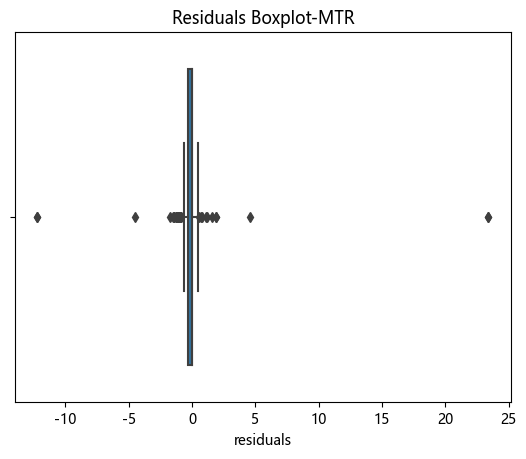

e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


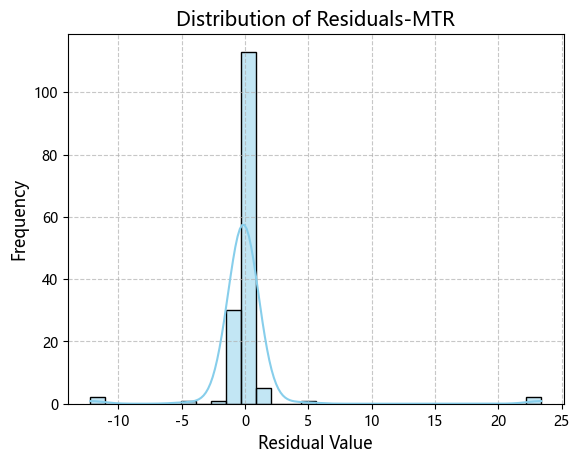

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 绘制箱线图
sns.boxplot(x=outlier['residuals'])
plt.title('Residuals Boxplot-MTR')
plt.show()

sns.histplot(outlier['residuals'], kde=True, bins=30, color='skyblue')
plt.title("Distribution of Residuals-MTR", fontsize=14)
plt.xlabel("Residual Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# 计算异常阈值
Q1 = outlier['residuals'].quantile(0.25)
Q3 = outlier['residuals'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 标记异常点
boxplot_outliers = outlier[ (outlier['residuals'] > upper_bound)]

In [ ]:
mean = outlier['residuals'].mean()
std = outlier['residuals'].std()
lower_sigma = mean - 2 * std
upper_sigma = mean + 2 * std

# 标记异常点
sigma_outliers = outlier[ (outlier['residuals'] > upper_sigma)]

In [ ]:
Selected_Routes=pd.read_excel("../Data/MTR/Selected_Routes.xlsx",engine="openpyxl")
original_data = original_data.join(Selected_Routes[['ON_DISTRICT']])

In [ ]:
boxplot_outliers_regions = original_data.loc[boxplot_outliers.index, 'ON_DISTRICT']
sigma_outliers_regions = original_data.loc[sigma_outliers.index, 'ON_DISTRICT']

In [ ]:
boxplot_outliers_regions

325     北區
456     沙田
318     北區
227     離島
104    深水埗
277     沙田
220    油尖旺
397     沙田
444     沙田
265    油尖旺
312     沙田
Name: ON_DISTRICT, dtype: object

In [ ]:
outlier['Lightgbm_Sigma_Outliers'] = np.where(
    outlier['residuals'] > upper_sigma,  # 条件
    1,                                   # 如果 True，赋值为 1
    0                                    # 如果 False，赋值为 0
)
outlier['Lightgbm_Box_Outliers'] = np.where(
    outlier['residuals'] > upper_bound,  # 条件
    1,                                   # 如果 True，赋值为 1
    0                                    # 如果 False，赋值为 0
)

In [ ]:
outlier = outlier.join(Selected_Routes[['ON_DISTRICT']])

In [ ]:
outlier.to_excel("../Data/MTR/visualized_outliers.xlsx",engine='openpyxl')

In [ ]:
# 检查预处理后的数据是否保留了原始索引
print("预处理数据索引是否与原始数据一致:", data.index.equals(original_data.index))

# 检查异常点的索引是否在原始数据中存在
print("箱线图异常点索引是否在原始数据中:", boxplot_outliers.index.isin(original_data.index).all())
print("标准差异常点索引是否在原始数据中:", sigma_outliers.index.isin(original_data.index).all())

预处理数据索引是否与原始数据一致: True
箱线图异常点索引是否在原始数据中: True
标准差异常点索引是否在原始数据中: True


In [ ]:
# 随机选择3个箱线图异常点
sample_outliers = boxplot_outliers.sample(3, random_state=42)

# 显示这些点的残差和对应区域
for idx, row in sample_outliers.iterrows():
    original_region = original_data.loc[idx, 'ON_DISTRICT']
    print(f"索引: {idx}, 残差: {row['residuals']:.2f}, 原始区域: {original_region}")

索引: 277, 残差: 0.76, 原始区域: 沙田
索引: 325, 残差: 23.39, 原始区域: 北區
索引: 265, 残差: 1.22, 原始区域: 油尖旺


In [ ]:
boxplot_outliers_regions

325     北區
456     沙田
318     北區
227     離島
104    深水埗
277     沙田
220    油尖旺
397     沙田
444     沙田
265    油尖旺
312     沙田
Name: ON_DISTRICT, dtype: object

In [ ]:


# 统计标准差法的异常区域分布
# sigma_region_counts = sigma_outliers_regions.value_counts(normalize=True) * 100
# print("标准差法异常区域占比:\n", sigma_region_counts)
# 统计箱线图法的异常区域分布
boxplot_region_counts = boxplot_outliers_regions.value_counts(normalize=True) * 100
print("Outlier Ratio by District:\n", boxplot_region_counts)


Outlier Ratio by District:
 ON_DISTRICT
沙田     45.454545
北區     18.181818
油尖旺    18.181818
離島      9.090909
深水埗     9.090909
Name: proportion, dtype: float64


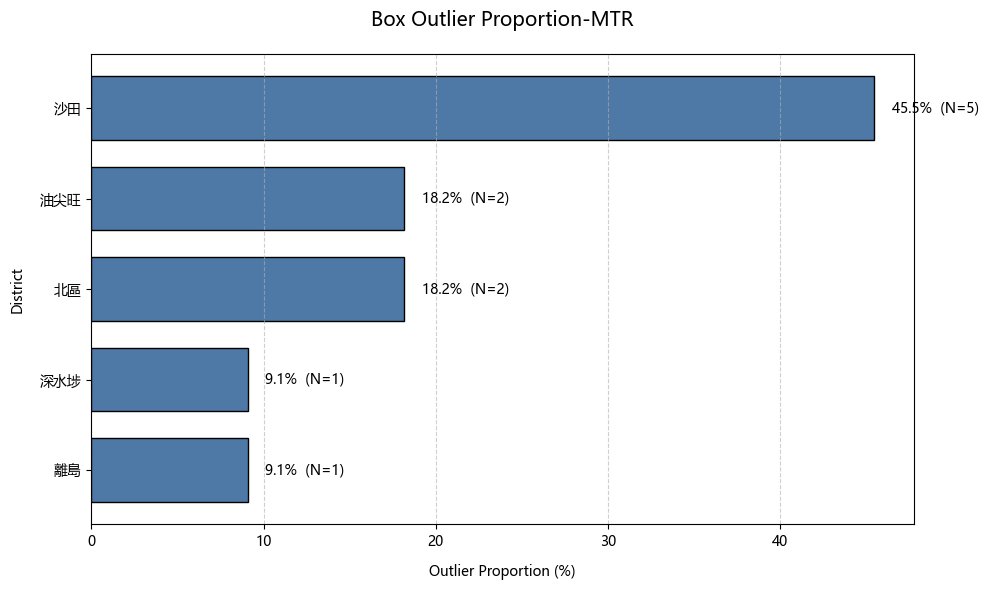

In [ ]:
import matplotlib as mpl
# 设置中文字体（解决乱码问题）
mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # Windows系统常用
# mpl.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac系统常用
mpl.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# plt.figure(figsize=(, 8))

counts = boxplot_outliers_regions.value_counts()
percentages = counts / counts.sum() * 100

# 创建图表
plt.figure(figsize=(10, 6))
ax = percentages.sort_values().plot(
    kind='barh',
    color='#4e79a7',
    edgecolor='black',
    width=0.7
)

# 添加双标签（个数 + 百分比）
for i, (p, count) in enumerate(zip(ax.patches, counts[percentages.sort_values().index])):
    width = p.get_width()
    ax.text(width + 1, 
            p.get_y() + p.get_height()/2, 
            f'{width:.1f}%  (N={count})',
            ha='left', 
            va='center')
# 图表装饰
plt.title('Box Outlier Proportion-MTR', pad=20, fontsize=14)
plt.xlabel('Outlier Proportion (%)', labelpad=10)
plt.ylabel('District', labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 调整边距
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 假设已有以下变量：
# boxplot_region_counts, sigma_region_counts, original_data

# 获取所有区域名称
all_regions = original_data['ON_DISTRICT'].unique()

# 箱线图法排名
boxplot_ranks = (
    boxplot_region_counts
    .reindex(all_regions, fill_value=0)
    .rank(method='min')
    .astype(int)
)

# 标准差法排名
sigma_ranks = (
    sigma_region_counts
    .reindex(all_regions, fill_value=0)
    .rank(method='min')
    .astype(int)
)

# 计算平均排名
average_ranks = (boxplot_ranks + sigma_ranks) / 2

# 整合结果
result = pd.DataFrame({
    '区域': all_regions,
    '箱线图法排名': boxplot_ranks,
    '标准差法排名': sigma_ranks,
    '平均排名': average_ranks.round(2)
}).sort_values('平均排名')
result

,区域,箱线图法排名,标准差法排名,平均排名
ON_DISTRICT,,,,
中西區,中西區,1,1,1.0
南區,南區,1,1,1.0
西貢,西貢,1,1,1.0
東區,東區,1,1,1.0
元朗,元朗,1,1,1.0
荃灣,荃灣,1,1,1.0
灣仔,灣仔,1,1,1.0
觀塘,觀塘,1,1,1.0
黃大仙,黃大仙,1,1,1.0


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


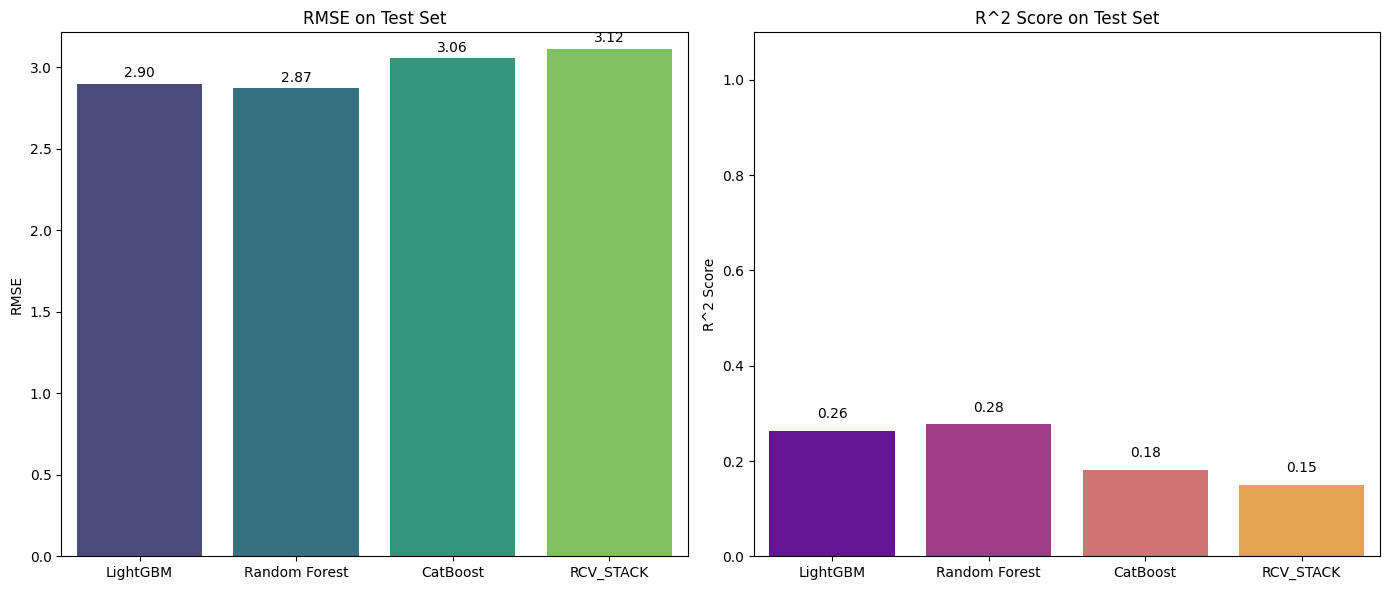

In [ ]:
# 数据整理

models = ['LightGBM', 'Random Forest', 'CatBoost','RCV_STACK']
rmse_scores = [lgb_rmse, rf_rmse, cat_rmse,rcv_stack_rmse]
r2_scores = [lgb_r2, rf_r2, cat_r2,rcv_stack_r2]

# 创建画布
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 绘制 RMSE 柱状图
sns.barplot(x=models, y=rmse_scores, ax=axes[0], palette='viridis')
axes[0].set_title('RMSE on Test Set')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, max(rmse_scores) + 0.1)  # 设置 y 轴范围

# 在柱子上标注数值
for i, score in enumerate(rmse_scores):
    axes[0].text(i, score + 0.02, f'{score:.2f}', ha='center', va='bottom')

# 绘制 R^2 柱状图
sns.barplot(x=models, y=r2_scores, ax=axes[1], palette='plasma')
axes[1].set_title('R^2 Score on Test Set')
axes[1].set_ylabel('R^2 Score')
axes[1].set_ylim(0, 1.1)  # 设置 y 轴范围

# 在柱子上标注数值
for i, score in enumerate(r2_scores):
    axes[1].text(i, score + 0.02, f'{score:.2f}', ha='center', va='bottom')

# 调整布局
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_graphviz
# 训练决策树模型
dt_regressor = DecisionTreeRegressor(
    max_depth=5,  # 控制树的最大深度（避免过深导致可视化不清晰）
    random_state=42
)
dt_regressor.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

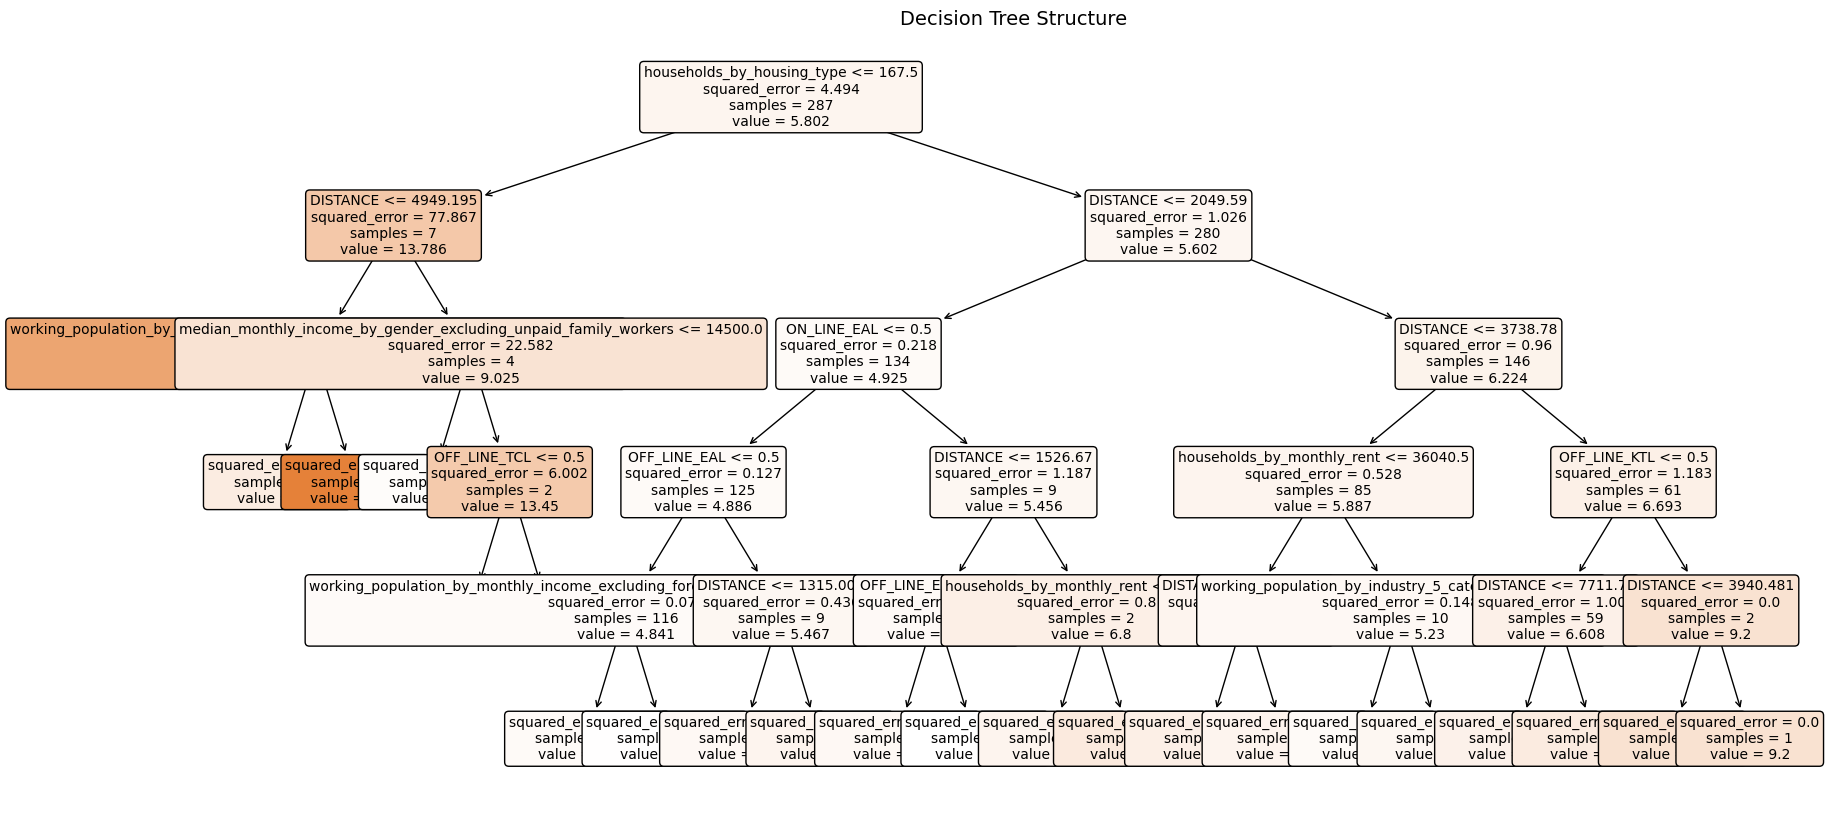

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_regressor,
    feature_names=X.columns,  # 显示特征名称
    filled=True,              # 填充颜色表示目标值
    rounded=True,             # 圆角节点
    fontsize=10
)
plt.title("Decision Tree Structure", fontsize=14)
plt.show()